# EchoROI: DICOM Dataset Preprocessing Pipeline

This notebook provides an end-to-end workflow for preprocessing echocardiography
DICOM datasets using the **ONNX EchoROI** model for ROI segmentation.

**Pipeline:**
1. Recursively discover DICOM files
2. Extract frames (optionally normalise to a fixed count via adaptive stride)
3. Resize to 256×256 (aspect-ratio preserving, zero-padded)
4. Select a **representative frame** (highest entropy) and run ONNX ROI inference
5. Broadcast the ROI mask, apply LV-focused square crop
6. Resize to 112×112 and save as compressed NPZ

**Why ONNX?**
- No TensorFlow dependency at inference time
- Hardware-accelerated via ONNX Runtime (CUDA, CoreML, DirectML)
- ~3× smaller than the Keras checkpoint

**Hardware:** Apple Mac mini (M2 Pro, 16 GB unified memory), macOS Sequoia 15.3

---

## 1. Setup

In [1]:
# ── Optional: Install dependencies ───────────────────────────────
# Uncomment and run this cell ONCE if the required packages are not
# already installed in your environment.  Then restart the kernel.

# !pip install onnxruntime opencv-python-headless numpy matplotlib scipy pydicom

# ── GPU acceleration (optional) ──────────────────────────────────
# For CUDA-accelerated inference, install onnxruntime-gpu instead:
# !pip install onnxruntime-gpu

# ── Apple Silicon (optional) ─────────────────────────────────────
# CoreML acceleration is included in the default onnxruntime package
# on macOS — no extra install needed.

print("Dependencies: skip this cell if already installed.")
print("Uncomment the pip line above, run once, then restart the kernel.")

Dependencies: skip this cell if already installed.
Uncomment the pip line above, run once, then restart the kernel.


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from scipy.stats import entropy as shannon_entropy
import onnxruntime as ort
import pydicom
import warnings
warnings.filterwarnings('ignore')

# Set working directory to project root
os.chdir(Path("__file__").resolve().parent.parent if "__file__" in dir() else Path.cwd().parent)

# print(f"Working dir:   {os.getcwd()}")
print(f"ONNX Runtime:  {ort.__version__}")
print(f"OpenCV:        {cv2.__version__}")
print(f"NumPy:         {np.__version__}")
print(f"pydicom:       {pydicom.__version__}")
print(f"Providers:     {ort.get_available_providers()}")
print("\n✓ All libraries loaded")

ONNX Runtime:  1.22.0
OpenCV:        4.8.1
NumPy:         1.26.4
pydicom:       3.0.1
Providers:     ['CoreMLExecutionProvider', 'AzureExecutionProvider', 'CPUExecutionProvider']

✓ All libraries loaded


## 2. Configuration

Key options:
- **`max_files`**: `None` = process all files; set to an integer to limit (e.g. `5` for a test run)
- **`target_frames`**: `None` = keep the original frame count; set to an integer (e.g. `32`) to normalise all clips to that length via adaptive stride

In [19]:
CONFIG = {
    # ── Paths ──
    'onnx_model_path': 'models/echoroi_unified.onnx',
    'input_dir':  '/path/to/dicom/files',  # set this to your DICOM directory
    'output_dir': '/path/to/output/directory',  # set this to your output directory

    # ── Frame extraction ──
    'target_frames': 32,          # None = keep all frames; int = adaptive stride to this count
    'echoroi_size':  (256, 256),  # model input size
    'final_size':    (112, 112),  # output crop size

    # ── Orientation fixes (dataset-specific) ──
    'flip_horizontal': False,
    'flip_vertical':   False,
    'rotate_90':       0,         # 0, 1, 2, or 3 quarter-turns

    # ── Batch processing ──
    'max_files': 10,              # None = process all; int = limit
    'compression': True,

    # ── Hardware ──
    'use_gpu': False,
}

# os.makedirs(CONFIG['output_dir'], exist_ok=True) Uncomment this line to create the output directory if it doesn't exist. Make sure to set 'output_dir' in CONFIG first.

print("Configuration:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

Configuration:
  onnx_model_path: models/echoroi_unified.onnx
  input_dir: /path/to/dicom/files
  output_dir: /path/to/output/directory
  target_frames: 32
  echoroi_size: (256, 256)
  final_size: (112, 112)
  flip_horizontal: False
  flip_vertical: False
  rotate_90: 0
  max_files: 10
  compression: True
  use_gpu: False


## 3. Load ONNX EchoROI Model

## 3. Load ONNX EchoROI Model

In [4]:
# Select execution provider
if CONFIG['use_gpu'] and 'CUDAExecutionProvider' in ort.get_available_providers():
    providers = ['CUDAExecutionProvider', 'CPUExecutionProvider']
elif 'CoreMLExecutionProvider' in ort.get_available_providers():
    providers = ['CoreMLExecutionProvider', 'CPUExecutionProvider']
else:
    providers = ['CPUExecutionProvider']

ort_session = ort.InferenceSession(CONFIG['onnx_model_path'], providers=providers)

input_name  = ort_session.get_inputs()[0].name
output_name = ort_session.get_outputs()[0].name

print(f"Model:      {CONFIG['onnx_model_path']}")
print(f"Input:      {input_name}  {ort_session.get_inputs()[0].shape}")
print(f"Output:     {output_name} {ort_session.get_outputs()[0].shape}")
print(f"Provider:   {ort_session.get_providers()[0]}")
print("\n✓ ONNX model loaded")

Model:      models/echoroi_unified.onnx
Input:      input  ['unk__226', 256, 256, 1]
Output:     segmentation_output ['unk__227', 256, 256, 1]
Provider:   CoreMLExecutionProvider

✓ ONNX model loaded


2026-03-04 07:21:06.897881 [W:onnxruntime:, coreml_execution_provider.cc:113 GetCapability] CoreMLExecutionProvider::GetCapability, number of partitions supported by CoreML: 5 number of nodes in the graph: 52 number of nodes supported by CoreML: 46


## 4. Helper Functions

All reusable processing functions are defined here and called by
both the single-file demo (§5) and the batch processor (§6).

In [5]:
# ── 4a. DICOM discovery ──────────────────────────────────────────

def find_dicom_files(root_dir):
    """Recursively find all .dcm files under root_dir."""
    dcm_files = []
    for root, _, files in os.walk(root_dir):
        for f in files:
            if f.lower().endswith('.dcm'):
                dcm_files.append(os.path.join(root, f))
    return sorted(dcm_files)


# ── 4b. Frame extraction ────────────────────────────────────────

def load_dicom_frames(dicom_path):
    """
    Load a DICOM file and return (frames, metadata).

    Handles 2-D (single frame), 3-D (grayscale video or single RGB),
    and 4-D (RGB video) pixel arrays.  Output is always
    (n_frames, height, width) uint8 grayscale.
    """
    ds = pydicom.dcmread(dicom_path)
    if not hasattr(ds, 'pixel_array'):
        raise ValueError("No pixel data in DICOM file")

    px = ds.pixel_array
    original_shape = px.shape

    if px.ndim == 4:
        frames = np.array([
            cv2.cvtColor(px[i].astype(np.uint8), cv2.COLOR_RGB2GRAY)
            if px.shape[3] == 3 else px[i, :, :, 0].astype(np.uint8)
            for i in range(px.shape[0])
        ])
    elif px.ndim == 3:
        if px.shape[0] < 10 and px.shape[0] in (1, 3, 4):
            if px.shape[0] == 3:
                rgb = np.transpose(px, (1, 2, 0)).astype(np.uint8)
                frames = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)[np.newaxis]
            else:
                frames = px[0:1].astype(np.uint8)
        else:
            frames = px
    elif px.ndim == 2:
        frames = px[np.newaxis]
    else:
        raise ValueError(f"Unexpected pixel shape: {px.shape}")

    if frames.dtype != np.uint8:
        lo, hi = frames.min(), frames.max()
        if hi > lo:
            frames = ((frames - lo) / (hi - lo) * 255).astype(np.uint8)
        else:
            frames = np.zeros_like(frames, dtype=np.uint8)

    metadata = {
        'path': dicom_path,
        'num_frames': len(frames),
        'height': frames.shape[1],
        'width': frames.shape[2],
        'patient_id': str(getattr(ds, 'PatientID', 'Unknown')),
        'study_date': str(getattr(ds, 'StudyDate', 'Unknown')),
        'original_shape': str(original_shape),
    }
    return frames, metadata


# ── 4c. Adaptive stride (optional) ──────────────────────────────

def adaptive_frame_selection(frames, target=None):
    """
    If target is None, return frames unchanged (keep original length).
    If target is an int, return exactly that many frames via
    even downsampling or linear interpolation.
    """
    if target is None:
        return frames

    n = len(frames)
    if n == target:
        return frames
    if n > target:
        idx = np.linspace(0, n - 1, target, dtype=int)
        return frames[idx]

    # Upsample via linear interpolation
    idx = np.linspace(0, n - 1, target)
    out = []
    for i in idx:
        lo, hi = int(np.floor(i)), min(int(np.ceil(i)), n - 1)
        w = i - lo
        blended = ((1 - w) * frames[lo].astype(np.float32) +
                   w * frames[hi].astype(np.float32))
        out.append(blended.astype(np.uint8))
    return np.array(out)


# ── 4d. Aspect-ratio resize + pad ───────────────────────────────

def pad_to_square(frame, target_size=(256, 256)):
    """Resize preserving aspect ratio, zero-pad to target_size."""
    h, w = frame.shape[:2]
    th, tw = target_size
    scale = min(th / h, tw / w)
    nh, nw = int(h * scale), int(w * scale)
    resized = cv2.resize(frame, (nw, nh), interpolation=cv2.INTER_AREA)
    ph, pw = (th - nh) // 2, (tw - nw) // 2
    pad_spec = ((ph, th - nh - ph), (pw, tw - nw - pw))
    if frame.ndim == 3:
        pad_spec += ((0, 0),)
    return np.pad(resized, pad_spec, mode='constant', constant_values=0)


def preprocess_frames(frames, target_size=(256, 256)):
    """
    Batch preprocess: grayscale → pad → normalise [0,1] → add channel dim.
    Returns float32 array (n, H, W, 1).
    """
    out = []
    for f in frames:
        g = cv2.cvtColor(f, cv2.COLOR_BGR2GRAY) if f.ndim == 3 and f.shape[2] == 3 else f.squeeze()
        p = pad_to_square(g, target_size)
        out.append(p.astype(np.float32) / 255.0)
    return np.expand_dims(np.array(out), axis=-1)


# ── 4e. Representative frame selection ───────────────────────────

def select_representative_frame(frames, n_candidates=8):
    """
    Pick the frame with the highest Shannon entropy from the first
    n_candidates frames.  Avoids blank / transition / calibration
    frames that often appear at index 0.

    Returns (best_index, frame_batch) where frame_batch is (1, H, W, C).
    """
    n = min(len(frames), n_candidates)
    best_idx, best_h = 0, -1.0
    for i in range(n):
        px = (frames[i, :, :, 0] * 255).astype(np.uint8)
        hist, _ = np.histogram(px, bins=256, range=(0, 256))
        prob = hist / hist.sum()
        h = float(shannon_entropy(prob, base=2))
        if h > best_h:
            best_h, best_idx = h, i
    return best_idx, frames[best_idx:best_idx + 1]


# ── 4f. ONNX inference ──────────────────────────────────────────

def predict_mask(session, image_batch):
    """Run ONNX inference.  Input: (1,256,256,1) float32."""
    return session.run(
        [session.get_outputs()[0].name],
        {session.get_inputs()[0].name: image_batch.astype(np.float32)}
    )[0]


# ── 4g. LV-focused square crop ──────────────────────────────────

def lv_square_crop(frames, masks, final_size=(112, 112)):
    """
    Apply mask → crop to ROI-centred square → resize to final_size.

    Parameters
    ----------
    frames : (N, H, W, 1) float32
    masks  : (N, H, W, 1) float32
    final_size : tuple

    Returns
    -------
    (cropped_frames, cropped_masks)  both (N, fh, fw, 1) float32
    """
    masked = frames * (masks > 0.5).astype(np.float32)
    m2d = masks[0, :, :, 0]
    coords = np.argwhere(m2d > 0.5)

    h, w = masked.shape[1:3]
    if len(coords) == 0:
        cs = min(h, w)
        y0, x0 = (h - cs) // 2, (w - cs) // 2
    else:
        ymin, xmin = coords.min(axis=0)
        ymax, xmax = coords.max(axis=0)
        cs = ymax - ymin + 1
        cx, cy = (xmin + xmax) // 2, (ymin + ymax) // 2
        x0 = max(0, min(cx - cs // 2, w - cs))
        y0 = max(0, min(cy - cs // 2, h - cs))

    crop_f = masked[:, y0:y0+cs, x0:x0+cs, :]
    crop_m = masks[:,  y0:y0+cs, x0:x0+cs, :]

    def _resize_stack(stack, sz, interp):
        out = []
        for i in range(len(stack)):
            r = cv2.resize(stack[i], sz, interpolation=interp)
            if r.ndim == 2:
                r = r[..., np.newaxis]
            out.append(r)
        return np.array(out)

    return (_resize_stack(crop_f, final_size, cv2.INTER_AREA),
            _resize_stack(crop_m, final_size, cv2.INTER_NEAREST))


# ── 4h. Save NPZ ────────────────────────────────────────────────

def save_npz(frames, output_path, compress=True):
    """Save frames array to (optionally compressed) NPZ."""
    if compress:
        np.savez_compressed(output_path, frames=frames)
    else:
        np.savez(output_path, frames=frames)
    return os.path.getsize(output_path) / 1024**2


print("✓ All helper functions defined")

✓ All helper functions defined


## 5. Single-File Demo

Process one DICOM file step-by-step with visualisation at each stage.

In [6]:
# Discover files
dicom_files = find_dicom_files(CONFIG['input_dir'])
print(f"Found {len(dicom_files)} DICOM files")

if len(dicom_files) == 0:
    raise FileNotFoundError(f"No .dcm files in {CONFIG['input_dir']}")

selected = dicom_files[0]
print(f"Selected: {os.path.basename(selected)}")

Found 3583 DICOM files
Selected: 01ee9bfe33d1974f33fd0833daad2e78_0000_0000.dcm


### 5.1 Load Frames

In [7]:
raw_frames, meta = load_dicom_frames(selected)
print(f"Loaded {meta['num_frames']} frames  ({meta['width']}×{meta['height']})")

Loaded 147 frames  (1016×708)


### 5.2 Frame Selection

If `target_frames` is set (e.g. `32`), adaptive stride normalises all clips to
that length.  If `None`, the original frame count is preserved.

In [8]:
frames_sel = adaptive_frame_selection(raw_frames, CONFIG['target_frames'])
n_out = len(frames_sel)
mode = f"adaptive stride → {n_out}" if CONFIG['target_frames'] else f"original ({n_out})"
print(f"Frame selection: {mode}  shape={frames_sel.shape}")

Frame selection: adaptive stride → 32  shape=(32, 708, 1016)


### 5.3 Resize to 256×256

In [9]:
frames_256 = preprocess_frames(frames_sel, CONFIG['echoroi_size'])
print(f"Preprocessed: {frames_256.shape}  dtype={frames_256.dtype}  "
      f"range=[{frames_256.min():.3f}, {frames_256.max():.3f}]")

Preprocessed: (32, 256, 256, 1)  dtype=float32  range=[0.000, 0.973]


### 5.4 Select Representative Frame & Run ROI Inference

Instead of blindly using the first frame (which may be blank or a
transition frame), we pick the frame with the highest **Shannon entropy**
from the first 8 candidates.

In [10]:
rep_idx, rep_frame = select_representative_frame(frames_256, n_candidates=8)
print(f"Representative frame: index {rep_idx}")

mask_raw = predict_mask(ort_session, rep_frame)
roi_mask = mask_raw[0]  # (256, 256, 1)
print(f"ROI coverage: {(roi_mask > 0.5).sum() / roi_mask.size:.1%}")

Representative frame: index 1
ROI coverage: 23.1%


### 5.5 Broadcast Mask & Apply LV Crop

In [11]:
masks_all = np.repeat(roi_mask[np.newaxis], len(frames_256), axis=0)

frames_final, masks_final = lv_square_crop(frames_256, masks_all, CONFIG['final_size'])
print(f"Output: {frames_final.shape}  dtype={frames_final.dtype}")

Output: (32, 112, 112, 1)  dtype=float32


### 5.6 Save NPZ

In [13]:
stem = Path(selected).stem
out_path = os.path.join(CONFIG['output_dir'], f"{stem}_preprocessed.npz")
size_mb = save_npz(frames_final, out_path, compress=CONFIG['compression'])
# print(f"Saved: {out_path}  ({size_mb:.2f} MB)")

### 5.7 Visualise Pipeline Stages

Three rows: 256×256 input → ROI overlay → final cropped output.
Columns show evenly spaced frames from the sequence.

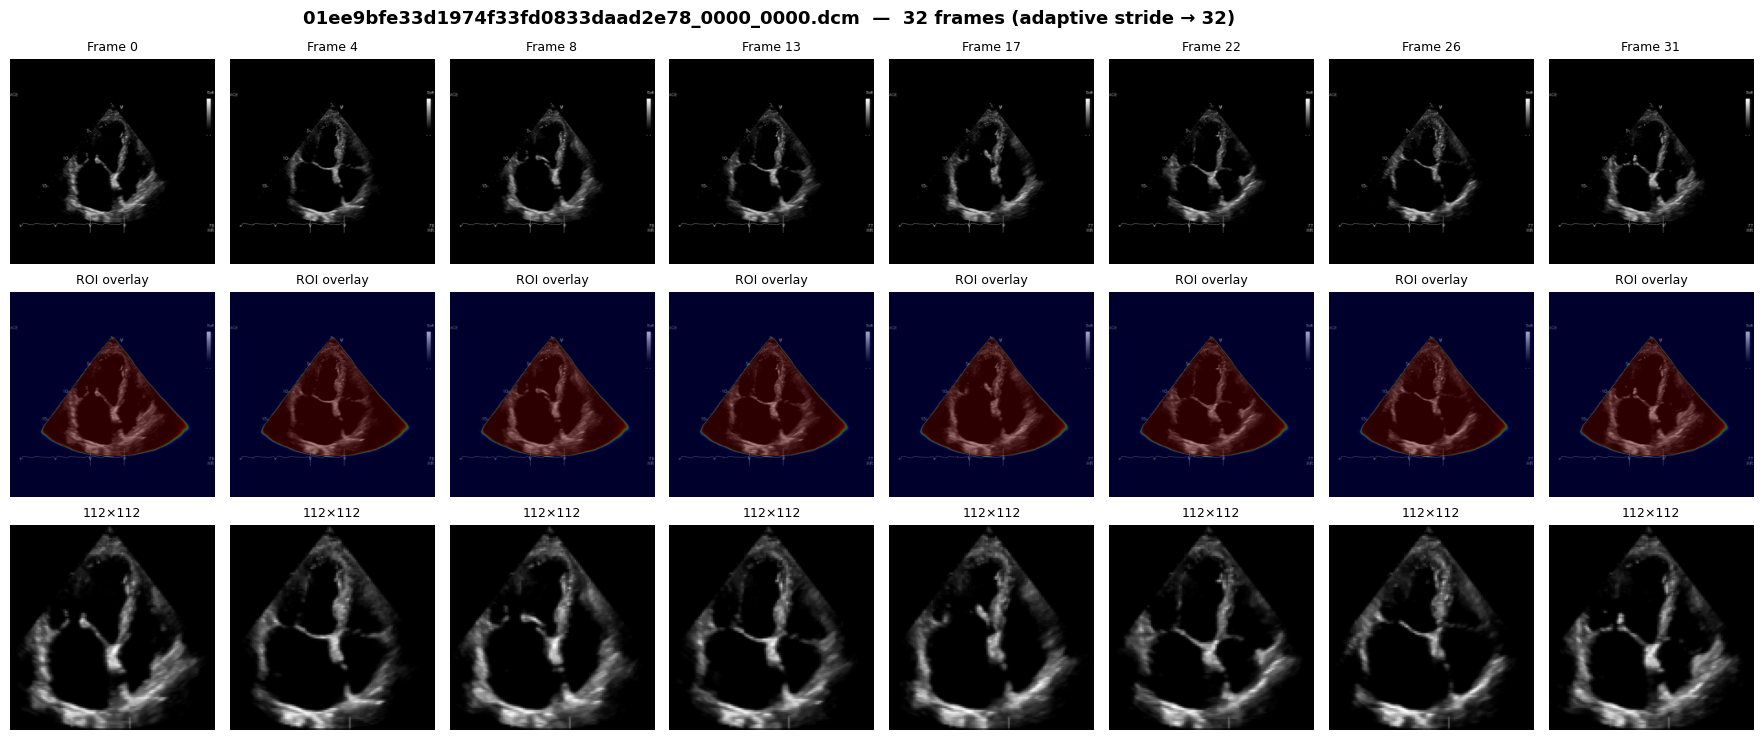

In [14]:
n_cols = min(8, len(frames_final))
sample_idx = np.linspace(0, len(frames_final) - 1, n_cols, dtype=int)

fig, axes = plt.subplots(3, n_cols, figsize=(2.5 * n_cols, 7.5))
if n_cols == 1:
    axes = axes[:, np.newaxis]

for col, si in enumerate(sample_idx):
    # Row 0: 256×256 input
    axes[0, col].imshow(frames_256[si, :, :, 0], cmap='gray')
    axes[0, col].set_title(f'Frame {si}', fontsize=9)
    axes[0, col].axis('off')

    # Row 1: ROI overlay
    axes[1, col].imshow(frames_256[si, :, :, 0], cmap='gray')
    axes[1, col].imshow(masks_all[si, :, :, 0], cmap='jet', alpha=0.35)
    axes[1, col].set_title('ROI overlay', fontsize=9)
    axes[1, col].axis('off')

    # Row 2: Final crop
    axes[2, col].imshow(frames_final[si, :, :, 0], cmap='gray')
    axes[2, col].set_title(f'{CONFIG["final_size"][0]}×{CONFIG["final_size"][1]}', fontsize=9)
    axes[2, col].axis('off')

for r, label in enumerate(['256×256 Input', 'ROI Overlay', f'{CONFIG["final_size"][0]}×{CONFIG["final_size"][1]} Output']):
    axes[r, 0].set_ylabel(label, fontsize=11, fontweight='bold',
                          rotation=0, labelpad=80, va='center', ha='right')

mode_str = f'{len(frames_final)} frames'
if CONFIG['target_frames']:
    mode_str += f' (adaptive stride → {CONFIG["target_frames"]})'
else:
    mode_str += ' (original length)'

plt.suptitle(f'{os.path.basename(selected)}  —  {mode_str}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(left=0.12)
plt.show()

## 6. Batch Processing

Process all DICOM files in the input directory (and subdirectories).

- Set `CONFIG['max_files'] = None` to process **all** files
- Set `CONFIG['max_files'] = 5` (or any int) for a **test run**
- Set `CONFIG['target_frames'] = None` to keep original frame counts
- Set `CONFIG['target_frames'] = 32` to normalise all clips to 32 frames

In [16]:
def batch_process(config, session):
    """
    Batch-process DICOM files → NPZ.

    Respects:
      config['max_files']:    None = all, int = limit
      config['target_frames']: None = keep original, int = adaptive stride
    """
    dcm_files = find_dicom_files(config['input_dir'])
    total = len(dcm_files)

    max_files = config.get('max_files')
    if max_files is not None:
        dcm_files = dcm_files[:max_files]
        print(f"Processing {len(dcm_files)} of {total} files (max_files={max_files})")
    else:
        print(f"Processing all {total} files")

    target = config.get('target_frames')
    if target:
        print(f"Adaptive stride: normalising to {target} frames per clip")
    else:
        print("Adaptive stride: OFF — keeping original frame counts")

    # print(f"Output → {config['output_dir']}\n{'='*70}")

    results = {
        'total': total, 'queued': len(dcm_files),
        'ok': 0, 'fail': 0, 'skipped': 0,
        'failed_files': [], 'output_files': [],
        't_start': datetime.now(),
    }

    for i, dcm_path in enumerate(dcm_files, 1):
        basename = os.path.basename(dcm_path)
        try:
            print(f"\n[{i}/{len(dcm_files)}] {basename}")

            # Load
            frames, _ = load_dicom_frames(dcm_path)
            print(f"  Loaded {len(frames)} frames")

            # Frame selection
            frames = adaptive_frame_selection(frames, target)
            print(f"  After selection: {len(frames)} frames")

            # Preprocess
            frames_pp = preprocess_frames(frames, config['echoroi_size'])

            # Representative frame → ROI mask
            rep_idx, rep_frame = select_representative_frame(frames_pp)
            mask = predict_mask(session, rep_frame)[0]
            masks = np.repeat(mask[np.newaxis], len(frames_pp), axis=0)
            print(f"  ROI from frame {rep_idx}  coverage={((mask > 0.5).sum() / mask.size):.1%}")

            # Crop
            cropped, _ = lv_square_crop(frames_pp, masks, config['final_size'])

            # Save
            stem = Path(dcm_path).stem
            out = os.path.join(config['output_dir'], f"{stem}_preprocessed.npz")
            sz = save_npz(cropped, out, compress=config['compression'])

            results['ok'] += 1
            results['output_files'].append(out)
            print(f"  ✓ {cropped.shape}  {sz:.2f} MB")

        except Exception as e:
            results['fail'] += 1
            results['failed_files'].append({'file': dcm_path, 'error': str(e)})
            print(f"  ✗ {e}")

    results['t_end'] = datetime.now()
    results['duration'] = results['t_end'] - results['t_start']

    print(f"\n{'='*70}")
    print(f"Batch complete")
    print(f"  ✓ Success:  {results['ok']}")
    print(f"  ✗ Failed:   {results['fail']}")
    print(f"  Duration:   {results['duration']}")
    if results['ok'] > 0:
        avg = results['duration'] / results['ok']
        print(f"  Avg/file:   {avg}")
    if results['failed_files']:
        print(f"\nFailed files:")
        for f in results['failed_files']:
            print(f"  {os.path.basename(f['file'])}: {f['error']}")
    print(f"{'='*70}")
    return results


batch_results = batch_process(CONFIG, ort_session)

Processing 10 of 3583 files (max_files=10)
Adaptive stride: normalising to 32 frames per clip

[1/10] 01ee9bfe33d1974f33fd0833daad2e78_0000_0000.dcm
  Loaded 147 frames
  After selection: 32 frames
  ROI from frame 1  coverage=23.1%
  ✓ (32, 112, 112, 1)  0.61 MB

[2/10] 01ee9bfe33d1974f33fd0833daad2e78_0000_0001.dcm
  Loaded 151 frames
  After selection: 32 frames
  ROI from frame 0  coverage=22.7%
  ✓ (32, 112, 112, 1)  0.66 MB

[3/10] 01ee9bfe33d1974f33fd0833daad2e78_0000_0002.dcm
  Loaded 132 frames
  After selection: 32 frames
  ROI from frame 1  coverage=24.0%
  ✓ (32, 112, 112, 1)  0.77 MB

[4/10] 01ee9bfe33d1974f33fd0833daad2e78_0000_0003.dcm
  Loaded 131 frames
  After selection: 32 frames
  ROI from frame 6  coverage=24.7%
  ✓ (32, 112, 112, 1)  0.77 MB

[5/10] 01ee9bfe33d1974f33fd0833daad2e78_0000_0004.dcm
  Loaded 133 frames
  After selection: 32 frames
  ROI from frame 1  coverage=24.2%
  ✓ (32, 112, 112, 1)  0.77 MB

[6/10] 01ee9bfe33d1974f33fd0833daad2e78_0001_0000.dcm
 

## 7. NPZ Inspector

Load any saved NPZ file, print per-frame statistics, and display all frames in a grid.
Useful to verify outputs from either the single-file demo or batch processing.

File:     01ee9bfe33d1974f33fd0833daad2e78_0000_0000_preprocessed.npz  (0.61 MB)
Shape:    (32, 112, 112, 1)  dtype=float32
Range:    [0.0000, 0.8088]
Non-zero: 41.5%


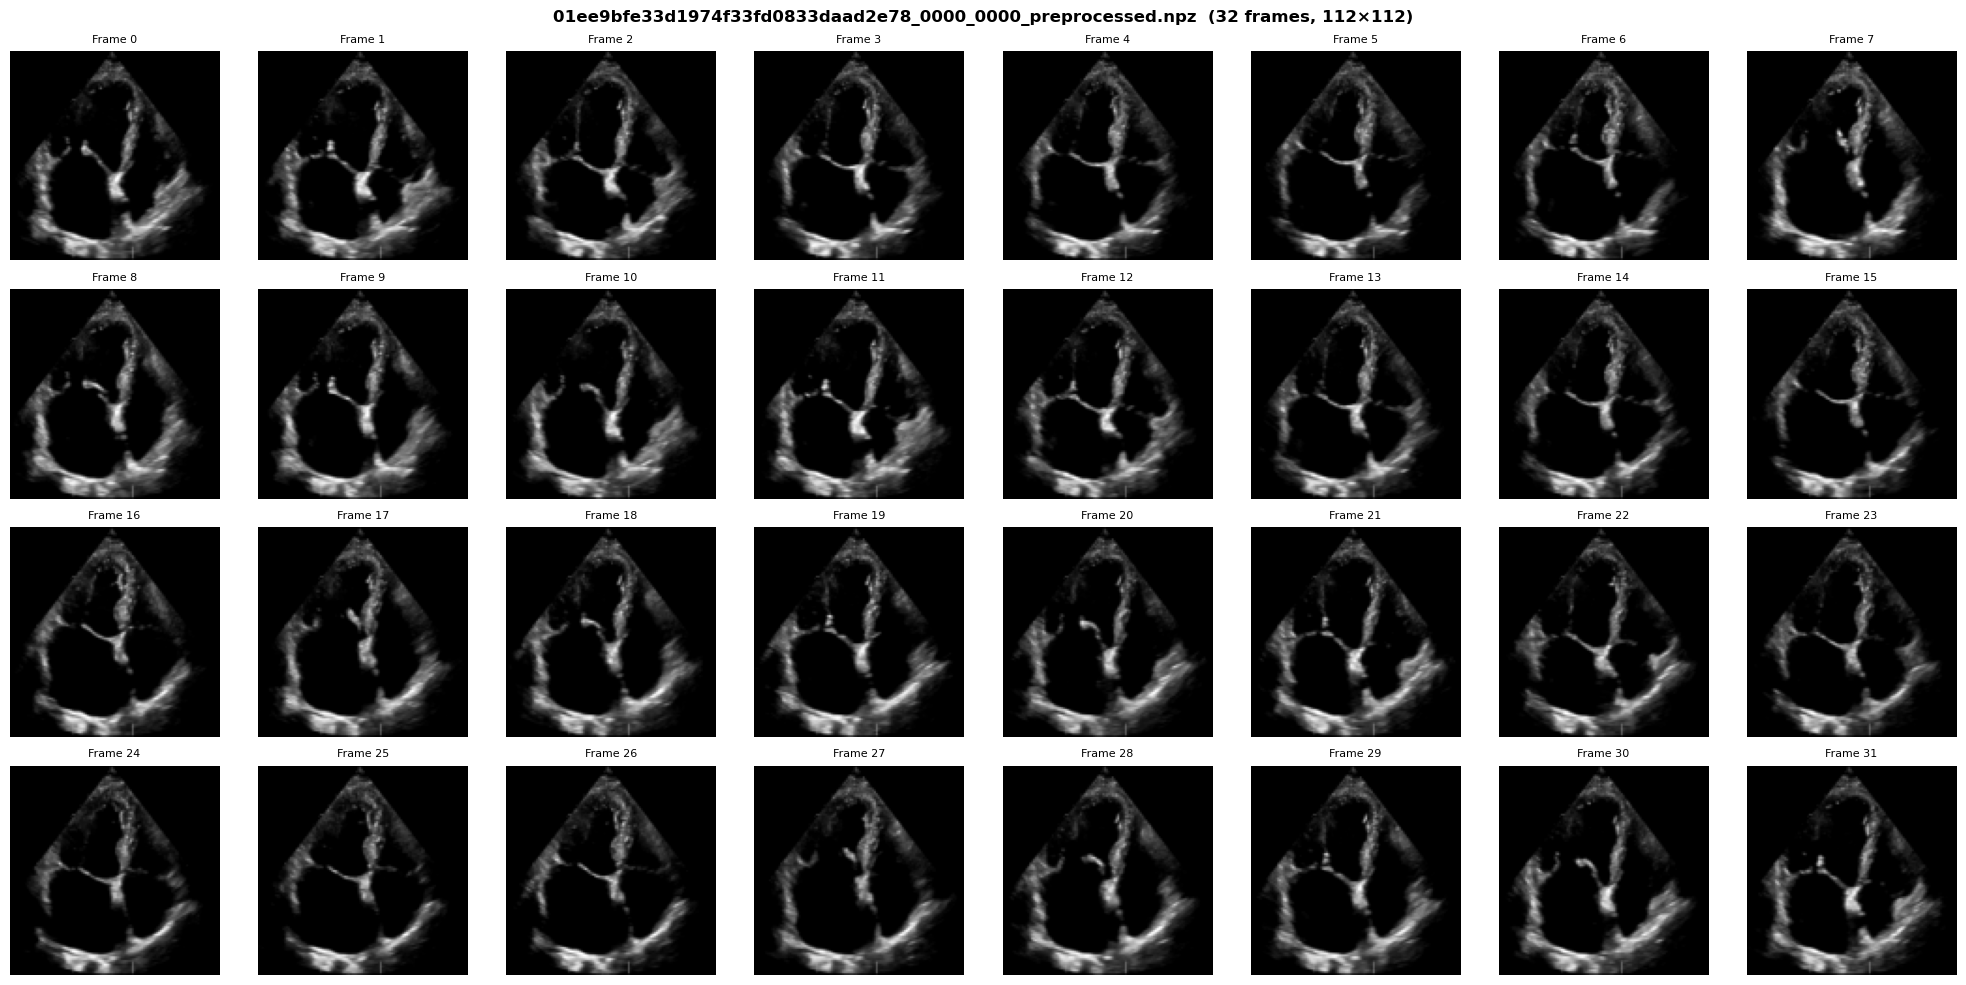

In [17]:
def inspect_npz(npz_path):
    """Load an NPZ file, print stats, and display all frames."""
    if not os.path.exists(npz_path):
        print(f"✗ Not found: {npz_path}")
        return

    data = np.load(npz_path, allow_pickle=True)
    frames = data['frames']
    size_mb = os.path.getsize(npz_path) / 1024**2
    n = len(frames)

    print(f"File:     {os.path.basename(npz_path)}  ({size_mb:.2f} MB)")
    print(f"Shape:    {frames.shape}  dtype={frames.dtype}")
    print(f"Range:    [{frames.min():.4f}, {frames.max():.4f}]")
    print(f"Non-zero: {(frames > 0).sum() / frames.size:.1%}")

    # Grid display
    cols = min(8, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(2.5 * cols, 2.5 * rows))

    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = axes[np.newaxis, :]
    elif cols == 1:
        axes = axes[:, np.newaxis]

    axes_flat = axes.flatten()

    for i in range(n):
        f = frames[i, :, :, 0]
        display = (f * 255).astype(np.uint8) if f.max() <= 1.0 else f.astype(np.uint8)
        axes_flat[i].imshow(display, cmap='gray')
        axes_flat[i].set_title(f'Frame {i}', fontsize=8)
        axes_flat[i].axis('off')

    for i in range(n, len(axes_flat)):
        axes_flat[i].axis('off')

    plt.suptitle(f'{os.path.basename(npz_path)}  ({n} frames, {frames.shape[1]}×{frames.shape[2]})',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Inspect the file from the single-file demo
inspect_npz(out_path)

# Or inspect any specific file:
# inspect_npz('/path/to/your/file.npz')